In [41]:
#importing libraries

import pandas as pd #dataframe
import seaborn as sns #plotting

# ANOVA / MANOVA / Regression Libraries

from statsmodels.formula.api import ols #Anova model
import statsmodels.api as sm #Anova Summary
from statsmodels.stats.multicomp import pairwise_tukeyhsd #tukeyhsd hsd
import statsmodels.formula.api as smf #regression

In [113]:
#import data

df_train = pd.read_csv(r"indian-urban-house-price-prediction/train.csv")
df_test = pd.read_csv(r"indian-urban-house-price-prediction/test.csv")

In [110]:
#Check for nulls

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Property_ID                 20000 non-null  object 
 1   City                        20000 non-null  object 
 2   Locality_Type               20000 non-null  object 
 3   Property_Type               20000 non-null  object 
 4   BHK                         20000 non-null  int64  
 5   Bathrooms                   20000 non-null  int64  
 6   Super_Area_SqFt             20000 non-null  float64
 7   Carpet_Area_SqFt            20000 non-null  float64
 8   Floor_Number                20000 non-null  int64  
 9   Total_Floors                20000 non-null  int64  
 10  Age_of_Property             20000 non-null  int64  
 11  Furnishing_Status           20000 non-null  object 
 12  Parking                     20000 non-null  int64  
 13  Lift_Available              200

In [5]:
df_train.head()

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs
0,PROP-005003,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,Semi-Furnished,1,1,1,5.34,10.84,127.38
1,PROP-009920,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,1,1,1,3.48,8.69,214.61
2,PROP-003987,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,Semi-Furnished,0,0,1,2.66,5.73,162.56
3,PROP-084186,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,1,1,0,1.33,10.70,124.88
4,PROP-068764,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,Unfurnished,0,1,0,1.75,7.22,94.77


Index(['Property_ID', 'City', 'Locality_Type', 'Property_Type', 'BHK',
       'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number',
       'Total_Floors', 'Age_of_Property', 'Furnishing_Status', 'Parking',
       'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km',
       'Distance_to_City_Center_km', 'Price_INR_Lakhs'],
      dtype='object')

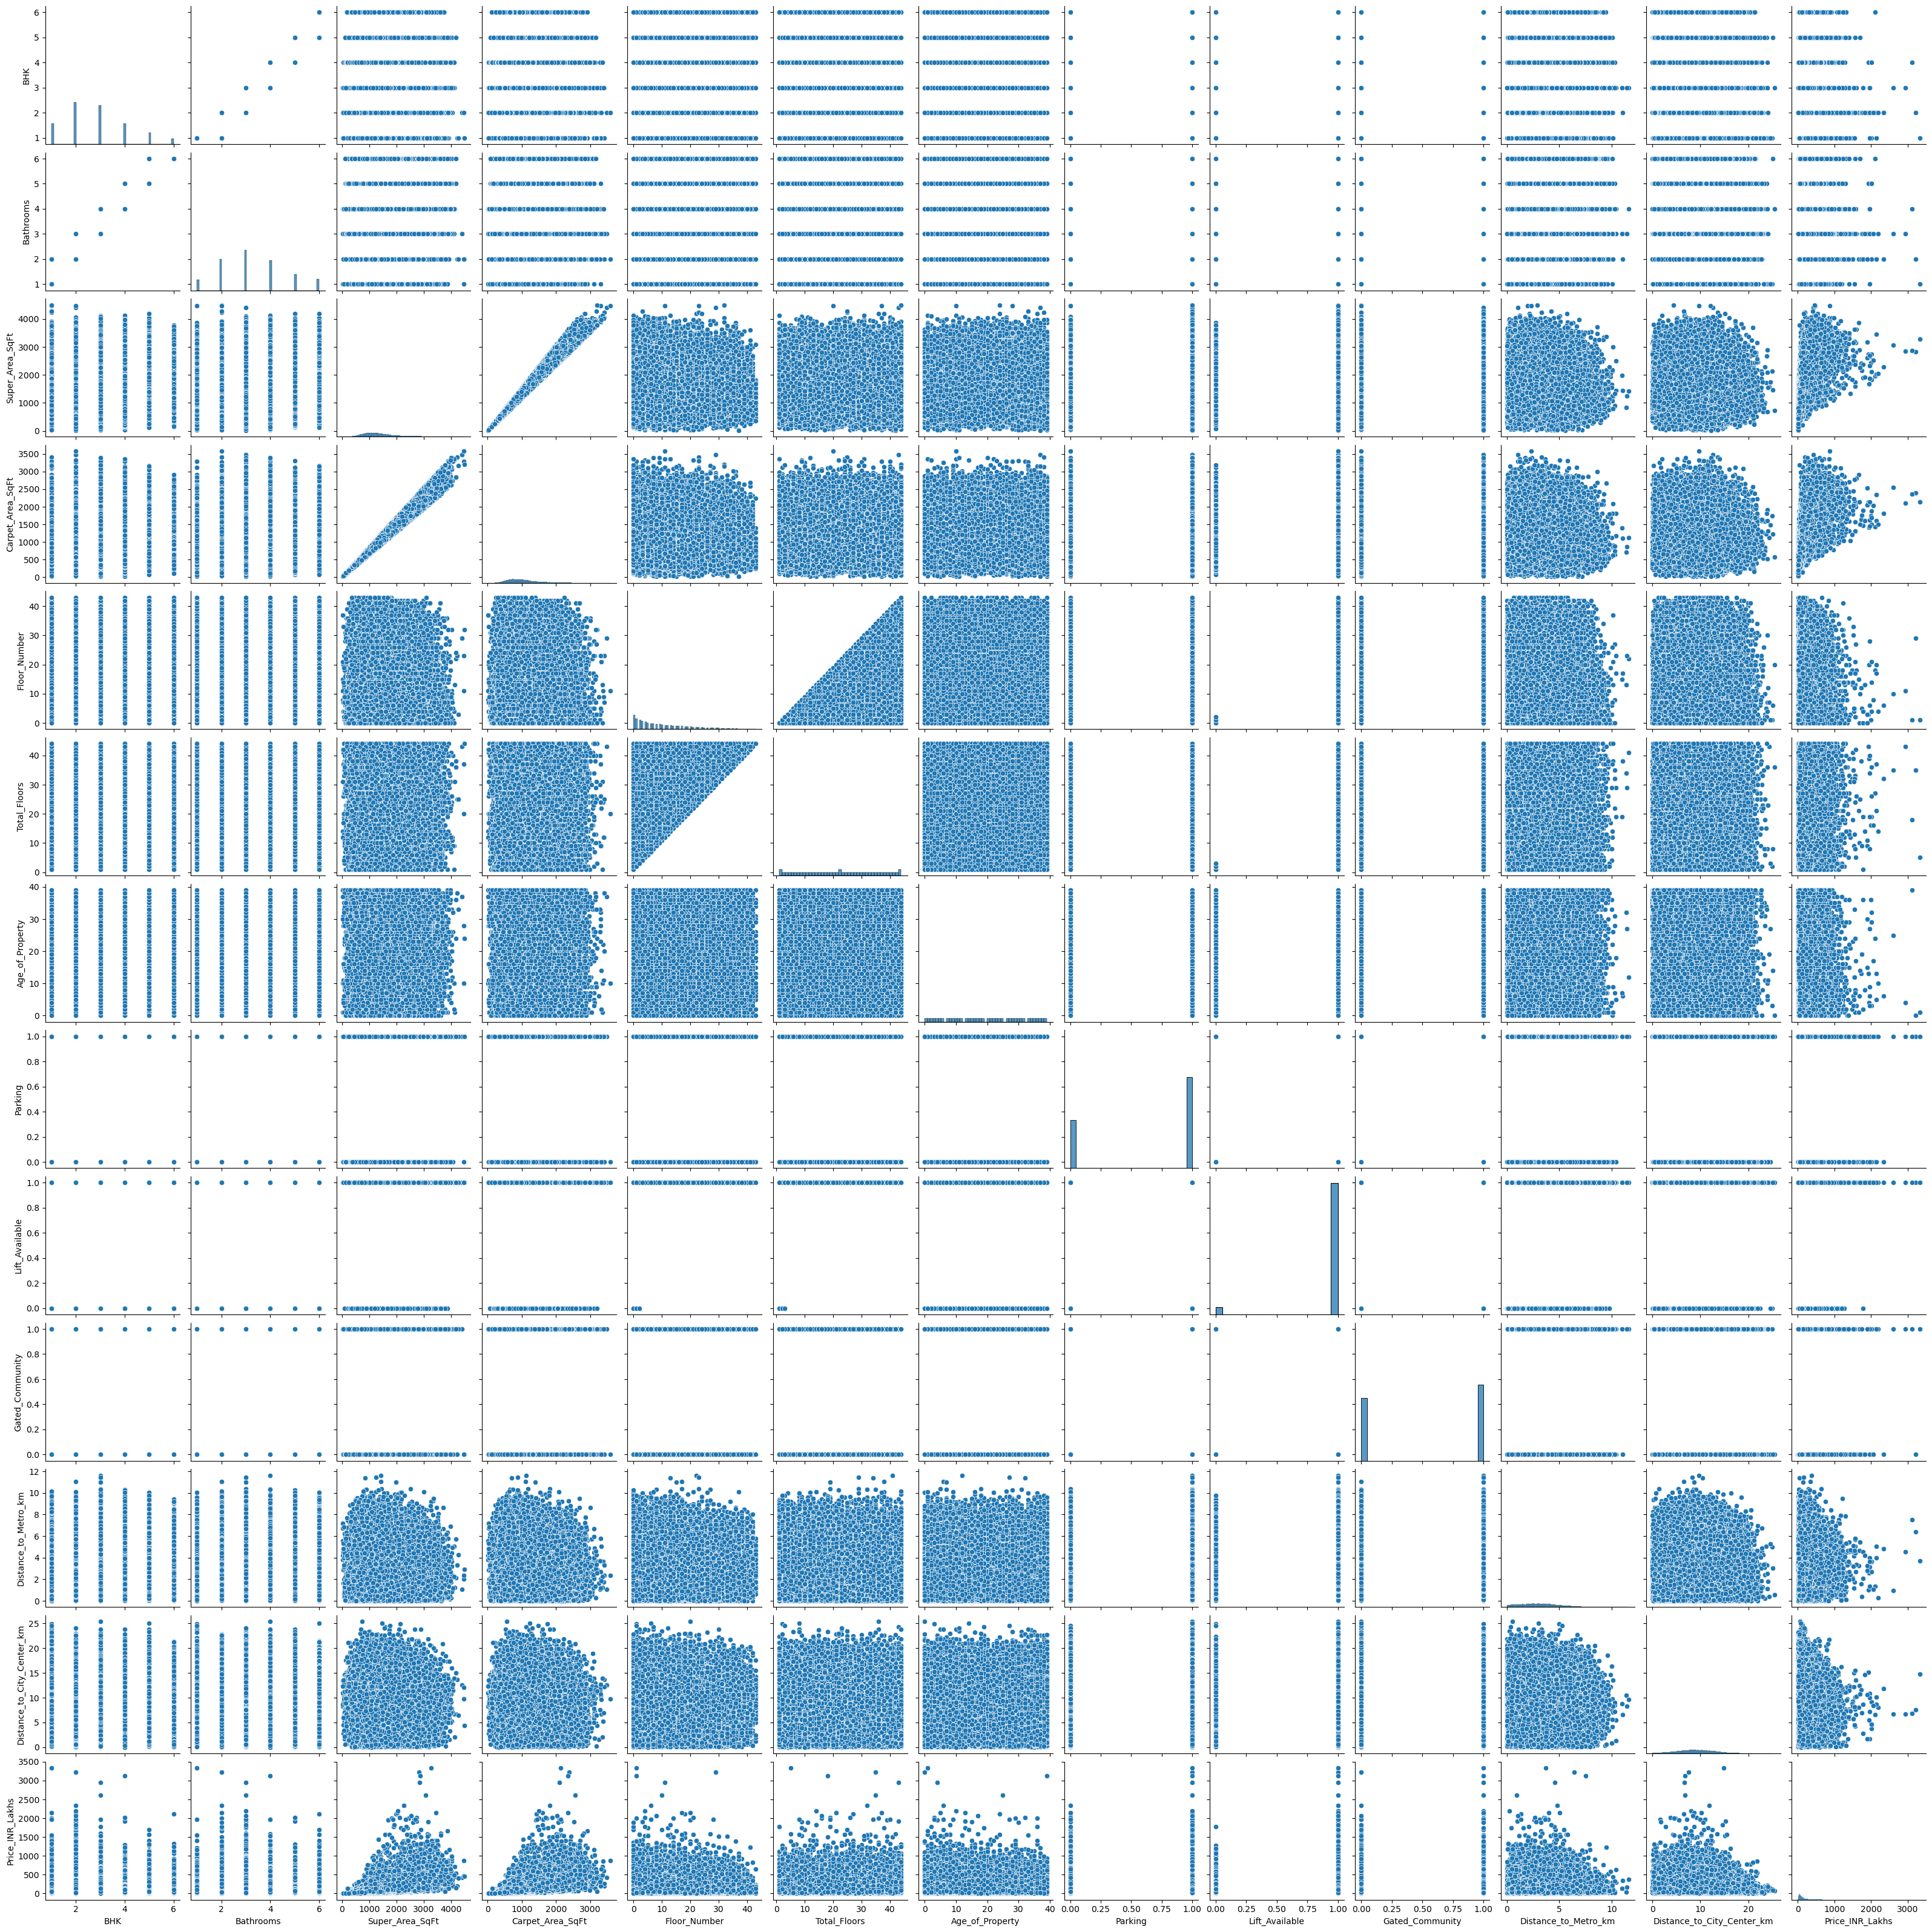

In [6]:
sns.pairplot(df_train)
df_train.columns

In [7]:
#Checking for number of unique values

df_train["Locality_Type"].value_counts()

Locality_Type
Mid-Range     40243
Affordable    19972
Premium       19785
Name: count, dtype: int64

### Data Transformation

In [8]:
df_train_pp = pd.get_dummies(df_train, columns=['Property_Type', 'City'], drop_first=True)

In [15]:
# checking if ordinal Variables are actully ordinal using ANOVA
#ordinal are factors having level or hierarchy

fit = ols("Price_INR_Lakhs ~ Locality_Type", data = df_train_pp).fit()
anova = sm.stats.anova_lm(fit, type = 1)

# p value < 0.05 hence there is a significant difference between the means of Locality_Type hence they will be ordinal
# now we want to see what order they are in

anova

,df,sum_sq,mean_sq,F,PR(>F)
Locality_Type,2.0,5.775233e+08,2.887616e+08,19967.493979,0.0
Residual,79997.0,1.156884e+09,1.446159e+04,NaN,NaN


In [17]:
# Use tpairwise_tukeyhsd to find order
# Here we know all follow an order as p-adj value is < 0.05
# group 2 - group 1 , hence Affordable < Mid-Range < Premium
# You can use one tailed T_test to confrim the above statement 

tukey1 = pairwise_tukeyhsd(df_train_pp['Price_INR_Lakhs'], groups=df_train_pp['Locality_Type'])
tukey1._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
Affordable,Mid-Range,58.9243,0.0,56.4847,61.3639,True
Affordable,Premium,228.2426,0.0,225.4155,231.0697,True
Mid-Range,Premium,169.3183,0.0,166.871,171.7656,True


In [18]:
Ltype_map = {"Affordable" : 1, "Mid-Range" : 2, "Premium" : 3}
df_train_pp["Locality_Type"] = df_train_pp["Locality_Type"].map(Ltype_map)

In [21]:
df_train_pp

,Property_ID,Locality_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,...,Property_Type_Villa,City_Bangalore,City_Chandigarh,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Mumbai,City_Pune
0,PROP-005003,2,4,5,1293.82,862.81,21,36,11,Semi-Furnished,...,False,False,True,False,False,False,False,False,False,False
1,PROP-009920,3,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,...,False,False,False,False,False,False,False,True,False,False
2,PROP-003987,2,3,4,1065.54,721.68,2,3,32,Semi-Furnished,...,True,False,False,False,True,False,False,False,False,False
3,PROP-084186,2,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,...,False,False,True,False,False,False,False,False,False,False
4,PROP-068764,3,5,5,1043.93,781.81,21,30,23,Unfurnished,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,PROP-093959,1,2,3,819.46,562.11,1,6,37,Semi-Furnished,...,False,False,False,False,False,False,True,False,False,False
79996,PROP-069155,1,4,4,711.22,483.28,24,30,16,Unfurnished,...,False,False,True,False,False,False,False,False,False,False
79997,PROP-001129,2,2,3,1223.19,835.26,17,27,17,Unfurnished,...,True,False,False,True,False,False,False,False,False,False
79998,PROP-062446,1,2,3,439.18,338.47,3,29,28,Furnished,...,False,False,False,False,False,True,False,False,False,False


In [23]:
# Now checking for Furnishing_Status

df_train_pp["Furnishing_Status"].value_counts()

Furnishing_Status
Semi-Furnished    26801
Furnished         26783
Unfurnished       26416
Name: count, dtype: int64

In [32]:
# what if there are multiple variables do you perform seprate anovas?
# use "+" to check multiple anovas
# Always use "+" as it is most seen irl as it shows dependency on other variables


fit = ols("Price_INR_Lakhs ~ Furnishing_Status + Locality_Type", data = df_train).fit()
anova2 = sm.stats.anova_lm(fit, type=1)
anova2

# P value > 0.05 hence there isnt any significant difference so we treat it as catrgorical

,df,sum_sq,mean_sq,F,PR(>F)
Furnishing_Status,2.0,7.456100e+04,3.728050e+04,2.578111,0.075924
Locality_Type,2.0,5.775731e+08,2.887865e+08,19970.863006,0.000000
Residual,79995.0,1.156759e+09,1.446039e+04,NaN,NaN


In [33]:
df_train_pp = pd.get_dummies(df_train, columns=['Property_Type', 'City', "Furnishing_Status"])

### Model Making

In [53]:
df_train.columns

Index(['Property_ID', 'City', 'Locality_Type', 'Property_Type', 'BHK',
       'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number',
       'Total_Floors', 'Age_of_Property', 'Furnishing_Status', 'Parking',
       'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km',
       'Distance_to_City_Center_km', 'Price_INR_Lakhs'],
      dtype='object')

In [48]:
lm_fit1=smf.ols("Price_INR_Lakhs ~ Locality_Type+ BHK + Bathrooms + Super_Area_SqFt + Carpet_Area_SqFt + Floor_Number + Total_Floors + Age_of_Property +Parking + Lift_Available + Gated_Community + Distance_to_Metro_km +Distance_to_City_Center_km +Property_Type_Apartment+Property_Type_Independent House+ Property_Type_Villa+City_Ahmedabad+ City_Bangalore+ City_Chandigarh+ City_Chennai+City_Delhi+ City_Hyderabad+City_Jaipur City_KolkataCity_Mumbai City_Pune + Furnishing_Status_FurnishedFurnishing_Status_Semi-Furnished + Furnishing_Status_Unfurnished", df_train_pp).fit()
lm_fit1.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Price_INR_Lakhs   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     6013.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:52:20   Log-Likelihood:            -4.6854e+05
No. Observations:               80000   AIC:                         9.371e+05
Df Residuals:                   79972   BIC:                         9.374e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 9.1662      1.928      4.755      0.000       5.388      12.944
Locality_Type[T.Mid-Range]                9.6585      0.803     12.025      0.000       8.084      11.233
Locality_Type[T.Premium]                 80.8500      1.307     61.839      0.000      78.287      83.413
Property_Type_Apartment[T.True]           0.3112      0.732      0.425      0.671      -1.124       1.747
Property_Type_Villa[T.True]               1.2890      0.733      1.759      0.079      -0.147       2.725
City_Ahmedabad[T.True]                  -66.3665      0.918    -72.263      0.000     -68.167     -64.566
City_Bangalore[T.True]                    9.1112      0.910     10.014      0.000       7.328      10.894
City_Chandigarh[T.True]                 -14.8215      0.925    -16.032      0.000     -16.634     -13.009
City_Chennai[T.True]                    -19.6294      0.912    -21.527      0.000     -21.417     -17.842
City_Delhi[T.True]                       86.9559      0.915     94.983      0.000      85.162      88.750
City_Hyderabad[T.True]                  -25.1262      0.915    -27.447      0.000     -26.920     -23.332
City_Jaipur[T.True]                     -76.5475      0.916    -83.543      0.000     -78.343     -74.752
City_Kolkata[T.True]                    -42.7486      0.925    -46.224      0.000     -44.561     -40.936
City_Mumbai[T.True]                     166.7592      0.917    181.902      0.000     164.962     168.556
City_Pune[T.True]                        -8.4203      0.926     -9.089      0.000     -10.236      -6.605
Furnishing_Status_Furnished[T.True]       0.2824      0.731      0.386      0.699      -1.150       1.715
Furnishing_Status_Unfurnished[T.True]     1.9286      0.734      2.629      0.009       0.491       3.366
BHK                                      -0.4064      0.623     -0.652      0.514      -1.628       0.815
Bathrooms                                 0.1851      0.601      0.308      0.758      -0.993       1.364
Super_Area_SqFt                           0.1093      0.003     41.782      0.000       0.104       0.114
Carpet_Area_SqFt                         -0.0004      0.003     -0.112      0.911      -0.007       0.006
Floor_Number                              0.0340      0.040      0.845      0.398      -0.045       0.113
Total_Floors                             -0.0090      0.032     -0.277      0.782      -0.072       0.054
Age_of_Property                          -1.3379      0.026    -51.523      0.000      -1.389      -1.287
Parking                                   2.9064      0.629      4.619      0.000       1.673       4.140
Lift_Available                            5.5876      1.455      3.841      0.000       2.736       8.439
Gated_Com

In [ ]:
lm_fit1=smf.ols("Price_INR_Lakhs ~ Locality_Type+ BHK + Bathrooms + Super_Area_SqFt + Carpet_Area_SqFt + Floor_Number + Total_Floors + Age_of_Property +Parking + Lift_Available + Gated_Community + Distance_to_Metro_km +Distance_to_City_Center_km +Property_Type_Apartment+ Property_Type_Villa+City_Ahmedabad+ City_Bangalore+ City_Chandigarh+ City_Chennai+City_Delhi+ City_Hyderabad+City_Jaipur + City_Kolkata+City_Mumbai+City_Pune + Furnishing_Status_Furnished + Furnishing_Status_Unfurnished", df_train_pp).fit()
lm_fit1.summary() 

In [50]:
df_train

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs
0,PROP-005003,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,Semi-Furnished,1,1,1,5.34,10.84,127.38
1,PROP-009920,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,1,1,1,3.48,8.69,214.61
2,PROP-003987,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,Semi-Furnished,0,0,1,2.66,5.73,162.56
3,PROP-084186,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,1,1,0,1.33,10.70,124.88
4,PROP-068764,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,Unfurnished,0,1,0,1.75,7.22,94.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,PROP-093959,Jaipur,Affordable,Independent House,2,3,819.46,562.11,1,6,37,Semi-Furnished,1,1,1,4.45,9.22,18.80
79996,PROP-069155,Chandigarh,Affordable,Builder Floor,4,4,711.22,483.28,24,30,16,Unfurnished,1,1,1,1.09,8.13,30.90
79997,PROP-001129,Chennai,Mid-Range,Villa,2,3,1223.19,835.26,17,27,17,Unfurnished,1,1,0,2.53,0.53,129.89
79998,PROP-062446,Hyderabad,Affordable,Apartment,2,3,439.18,338.47,3,29,28,Furnished,1,1,1,5.18,14.35,15.44


In [75]:
lm_fit1=smf.ols("Price_INR_Lakhs ~ C(City) + C(Locality_Type) + C(Furnishing_Status) + Parking + Super_Area_SqFt + Age_of_Property + Lift_Available + Gated_Community + Distance_to_Metro_km + Distance_to_City_Center_km", df_train).fit()
lm_fit1.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Price_INR_Lakhs   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     8118.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:07:33   Log-Likelihood:            -4.6854e+05
No. Observations:               80000   AIC:                         9.371e+05
Df Residuals:                   79979   BIC:                         9.373e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                -57.0266      2.158    -26.426      0.000     -61.256     -52.797
C(City)[T.Bangalore]                      75.4769      1.331     56.715      0.000      72.869      78.085
C(City)[T.Chandigarh]                     51.5524      1.344     38.360      0.000      48.918      54.186
C(City)[T.Chennai]                        46.7332      1.332     35.076      0.000      44.122      49.345
C(City)[T.Delhi]                         153.3348      1.337    114.689      0.000     150.714     155.955
C(City)[T.Hyderabad]                      41.2533      1.336     30.876      0.000      38.635      43.872
C(City)[T.Jaipur]                        -10.1825      1.338     -7.608      0.000     -12.806      -7.559
C(City)[T.Kolkata]                        23.6245      1.345     17.566      0.000      20.989      26.261
C(City)[T.Mumbai]                        233.1238      1.338    174.298      0.000     230.502     235.745
C(City)[T.Pune]                           57.9398      1.346     43.059      0.000      55.302      60.577
C(Locality_Type)[T.Mid-Range]              9.6634      0.803     12.032      0.000       8.089      11.237
C(Locality_Type)[T.Premium]               80.8748      1.307     61.863      0.000      78.312      83.437
C(Furnishing_Status)[T.Semi-Furnished]    -0.2879      0.731     -0.394      0.694      -1.721       1.145
C(Furnishing_Status)[T.Unfurnished]        1.6494      0.734      2.248      0.025       0.211       3.088
Parking                                    2.9022      0.629      4.613      0.000       1.669       4.135
Super_Area_SqFt                            0.1090      0.001    148.119      0.000       0.108       0.110
Age_of_Property                           -1.3379      0.026    -51.525      0.000      -1.389      -1.287
Lift_Available                             5.7464      1.348      4.264      0.000       3.105       8.388
Gated_Community                            2.8631      0.601      4.764      0.000       1.685       4.041
Distance_to_Metro_km                       0.5023      0.164      3.057      0.002       0.180       0.824
Distance_to_City_Center_km                -3.4657      0.076    -45.482      0.000      -3.615      -3.316
==============================================================================
Omnibus:                    98057.115   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         38846765.382
Skew:                           6.258   Prob(JB):                         0.00
Kurtosis:                     110.226   Cond. No.                     1.66e+04
==============================================================================

Notes:
[1] Standard Errors assume that t

In [78]:
df_train_pp2 = pd.get_dummies(df_train, columns=["Furnishing_Status"])

In [87]:
df_train_pp2

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs,Furnishing_Status_Furnished,Furnishing_Status_Semi_Furnished,Furnishing_Status_Unfurnished
0,PROP-005003,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,1,1,1,5.34,10.84,127.38,False,True,False
1,PROP-009920,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,1,1,1,3.48,8.69,214.61,False,True,False
2,PROP-003987,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,0,0,1,2.66,5.73,162.56,False,True,False
3,PROP-084186,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,1,1,0,1.33,10.70,124.88,False,True,False
4,PROP-068764,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,0,1,0,1.75,7.22,94.77,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,PROP-093959,Jaipur,Affordable,Independent House,2,3,819.46,562.11,1,6,37,1,1,1,4.45,9.22,18.80,False,True,False
79996,PROP-069155,Chandigarh,Affordable,Builder Floor,4,4,711.22,483.28,24,30,16,1,1,1,1.09,8.13,30.90,False,False,True
79997,PROP-001129,Chennai,Mid-Range,Villa,2,3,1223.19,835.26,17,27,17,1,1,0,2.53,0.53,129.89,False,False,True
79998,PROP-062446,Hyderabad,Affordable,Apartment,2,3,439.18,338.47,3,29,28,1,1,1,5.18,14.35,15.44,True,False,False


In [91]:
lm_fit1=smf.ols("Price_INR_Lakhs ~ C(City) + C(Locality_Type) + Furnishing_Status_Furnished + Furnishing_Status_Unfurnished + Furnishing_Status_Semi_Furnished + Parking + Super_Area_SqFt + Age_of_Property + Lift_Available + Gated_Community + Distance_to_Metro_km + Distance_to_City_Center_km", df_train_pp2).fit()
lm_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Price_INR_Lakhs   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     8118.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:19:05   Log-Likelihood:            -4.6854e+05
No. Observations:               80000   AIC:                         9.371e+05
Df Residuals:                   79979   BIC:                         9.373e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                  -42.4296      1.586    -26.751      0.000     -45.538     -39.321
C(City)[T.Bangalore]                        75.4769      1.331     56.715      0.000      72.869      78.085
C(City)[T.Chandigarh]                       51.5524      1.344     38.360      0.000      48.918      54.186
C(City)[T.Chennai]                          46.7332      1.332     35.076      0.000      44.122      49.345
C(City)[T.Delhi]                           153.3348      1.337    114.689      0.000     150.714     155.955
C(City)[T.Hyderabad]                        41.2533      1.336     30.876      0.000      38.635      43.872
C(City)[T.Jaipur]                          -10.1825      1.338     -7.608      0.000     -12.806      -7.559
C(City)[T.Kolkata]                          23.6245      1.345     17.566      0.000      20.989      26.261
C(City)[T.Mumbai]                          233.1238      1.338    174.298      0.000     230.502     235.745
C(City)[T.Pune]                             57.9398      1.346     43.059      0.000      55.302      60.577
C(Locality_Type)[T.Mid-Range]                9.6634      0.803     12.032      0.000       8.089      11.237
C(Locality_Type)[T.Premium]                 80.8748      1.307     61.863      0.000      78.312      83.437
Furnishing_Status_Furnished[T.True]        -14.5970      0.678    -21.533      0.000     -15.926     -13.268
Furnishing_Status_Unfurnished[T.True]      -12.9476      0.674    -19.196      0.000     -14.270     -11.626
Furnishing_Status_Semi_Furnished[T.True]   -14.8849      0.679    -21.921      0.000     -16.216     -13.554
Parking                                      2.9022      0.629      4.613      0.000       1.669       4.135
Super_Area_SqFt                              0.1090      0.001    148.119      0.000       0.108       0.110
Age_of_Property                             -1.3379      0.026    -51.525      0.000      -1.389      -1.287
Lift_Available                               5.7464      1.348      4.264      0.000       3.105       8.388
Gated_Community                              2.8631      0.601      4.764      0.000       1.685       4.041
Distance_to_Metro_km                         0.5023      0.164      3.057      0.002       0.180       0.824
Distance_to_City_Center_km                  -3.4657      0.076    -45.482      0.000      -3.615      -3.316
==============================================================================
Omnibus:                    98057.115   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         38846765.382
Skew:                           6.258   Prob(JB):                         0.00
Kurtosis:                     110.226   Co

In [85]:
df_train_pp2.columns = df_train_pp2.columns.str.replace('-', '_')

In [92]:
df_test

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km
0,PROP-009209,Bangalore,Mid-Range,Independent House,2,3,1660.04,1360.59,13,26,2,Furnished,1,1,0,2.69,9.54
1,PROP-053772,Bangalore,Mid-Range,Independent House,3,4,1368.07,1147.28,0,3,28,Furnished,1,1,1,3.17,9.30
2,PROP-001197,Pune,Premium,Villa,1,2,3135.01,2316.97,15,17,15,Semi-Furnished,1,1,1,4.32,8.72
3,PROP-043368,Jaipur,Mid-Range,Villa,3,3,2057.51,1669.45,1,11,36,Unfurnished,1,1,0,1.93,8.50
4,PROP-058815,Delhi,Mid-Range,Villa,1,2,887.26,657.34,12,39,2,Unfurnished,1,1,1,1.60,5.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,PROP-031978,Jaipur,Premium,Independent House,3,3,951.04,708.79,2,10,21,Unfurnished,1,1,1,8.18,12.75
19996,PROP-088395,Ahmedabad,Mid-Range,Builder Floor,4,5,1969.96,1310.55,11,34,18,Furnished,1,1,0,4.51,12.26
19997,PROP-079949,Bangalore,Mid-Range,Villa,1,1,1762.78,1266.98,5,25,16,Furnished,1,1,1,2.45,6.34
19998,PROP-033562,Chennai,Premium,Builder Floor,2,2,716.35,558.76,1,2,36,Semi-Furnished,0,0,0,4.50,7.53


In [114]:

df_test = pd.get_dummies(df_test, columns=["Furnishing_Status"])
df_test.columns = df_test.columns.str.replace('-', '_')

xdf = df_train_pp2[["City", "Locality_Type" , "Furnishing_Status_Furnished" , "Furnishing_Status_Unfurnished" , "Furnishing_Status_Semi_Furnished" , "Parking" , "Super_Area_SqFt" , "Age_of_Property" , "Lift_Available" , "Gated_Community" , "Distance_to_Metro_km" , "Distance_to_City_Center_km"]]
xdf2 = df_test[["City", "Locality_Type" , "Furnishing_Status_Furnished" , "Furnishing_Status_Unfurnished" , "Furnishing_Status_Semi_Furnished" , "Parking" , "Super_Area_SqFt" , "Age_of_Property" , "Lift_Available" , "Gated_Community" , "Distance_to_Metro_km" , "Distance_to_City_Center_km"]]

price_pred = lm_fit2.predict(xdf2)
price_pred

0        183.311842
1        120.638925
2        386.594487
3        100.358204
4        193.589595
            ...    
19995     62.311125
19996    111.695855
19997    189.612245
19998     76.371572
19999    168.456739
Length: 20000, dtype: float64

In [116]:
output = pd.DataFrame({
    'Property_ID': df_test['Property_ID'],
    'Price_INR_Lakhs': price_pred
})

output.to_csv("predictions3.csv", index=False)

In [108]:
df_test.tail()

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs,Furnishing_Status_Furnished,Furnishing_Status_Semi_Furnished,Furnishing_Status_Unfurnished
79995,PROP-093959,Jaipur,Affordable,Independent House,2,3,819.46,562.11,1,6,37,1,1,1,4.45,9.22,18.80,False,True,False
79996,PROP-069155,Chandigarh,Affordable,Builder Floor,4,4,711.22,483.28,24,30,16,1,1,1,1.09,8.13,30.90,False,False,True
79997,PROP-001129,Chennai,Mid-Range,Villa,2,3,1223.19,835.26,17,27,17,1,1,0,2.53,0.53,129.89,False,False,True
79998,PROP-062446,Hyderabad,Affordable,Apartment,2,3,439.18,338.47,3,29,28,1,1,1,5.18,14.35,15.44,True,False,False
79999,PROP-059018,Chennai,Mid-Range,Independent House,4,4,1679.76,1325.90,29,30,13,1,1,0,3.30,6.62,108.75,True,False,False
